In [12]:


from functions import fourier3, fourier5, fourier6, Rabc, Quad, ChemShift, AntiShift
from scipy.interpolate import make_interp_spline
from scipy import optimize
from scipy.optimize import curve_fit
import sympy as sym
from sympy import *
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

In [13]:
w0 = 192.55 # larmor frequency for 11B
df = [0]*6
# Data for (-)8HQ(ipc)2B
df[0] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(-)8HQ_X_Rot', skiprows=[1]) #skipping row for frequency label
df[1] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(-)8HQ_Y_Rot', skiprows=[1,2]) #skipping row for frequency label and angle = -7
df[2] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(-)8HQ_Z_Rot', skiprows=[1])

# Data for (+)8HQ(ipc)2B
df[3] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(+)8HQ_X_Rot', skiprows=[1])
df[4] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(+)8HQ_Y_Rot', skiprows=[1])
df[5] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(+)8HQ_Z_Rot', skiprows=[1])



In [11]:
L_HQ_x = [[-2.243306, 1.428536, -3.522236, 0.219859, 0.004287], [-1.737070, 1.300349, 3.546710, -0.042379, -0.027416]] # coefficient from ASICS
L_HQ_y = [[-2.630916, 2.462382, 0.271774, -0.401864, -0.525906], [-2.748530, 2.593289, 1.011176, -0.325788, -0.557786]] # coefficient from ASICS
L_HQ_z = [[-3.468406, -1.138969, -0.574216, -0.939815, -1.094452], [-3.261651, -1.187894 ,-0.628636 ,-0.956962 ,-1.127200]] # coefficient from ASICS

# Fit for Mounting 1
angle_smooth = np.linspace(df[0].Angle.min(), df[0].Angle.max(), 200) #100 points for smooth curve
L_HQ_1_x = fourier5(angle_smooth, *L_HQ_x[0])
L_HQ_2_x = fourier5(angle_smooth, *L_HQ_x[1])

# Fit for Mounting 2
L_HQ_1_y = fourier5(angle_smooth, *L_HQ_y[0])
L_HQ_2_y = fourier5(angle_smooth, *L_HQ_y[1])

# Fit for Mounting 3
L_HQ_1_z = fourier5(angle_smooth, *L_HQ_z[0])
L_HQ_2_z = fourier5(angle_smooth, *L_HQ_z[1])

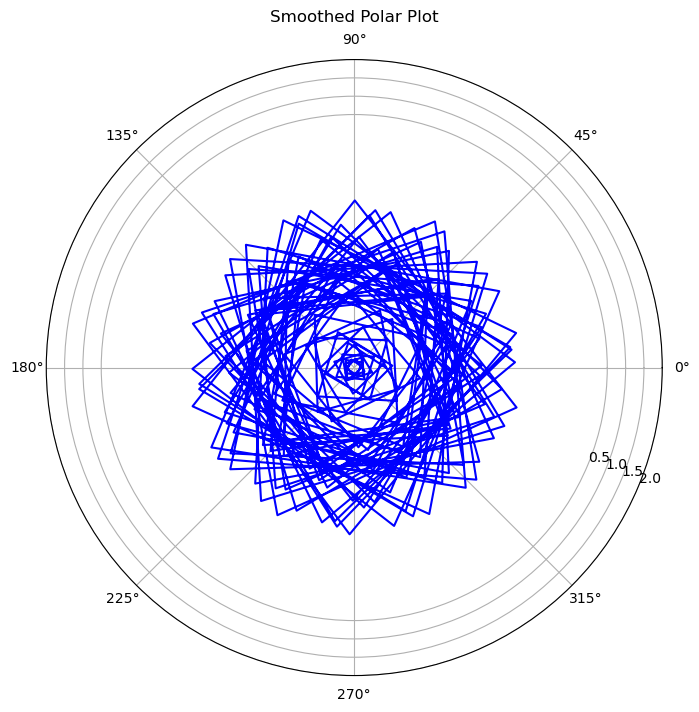

In [17]:


# Suppose your angle and value arrays look like this
angles = angle_smooth            # in degrees
values = L_HQ_1_z # convert units if needed

# Convert degrees to radians for polar plotting
angles_rad = np.deg2rad(angle_smooth)

# Interpolation
# f_interp = interp1d(angles_rad, values, kind='linear')  # 'linear', 'quadratic', or 'cubic'

# Create smooth angle array
# angles_smooth = np.linspace(min(angles_rad), max(angles_rad), 1000)
# values_smooth = f_interp(angles_smooth)

# values_smooth = fourier5(angles_smooth, *L)

# Plot
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8,8))
ax.plot(angle_smooth, values, color='blue')
ax.set_rmax(2)
ax.set_rticks([0.5, 1, 1.5, 2])
ax.set_rlabel_position(-22.5)
ax.grid(True)

ax.set_title("Smoothed Polar Plot", va='bottom')
plt.show()

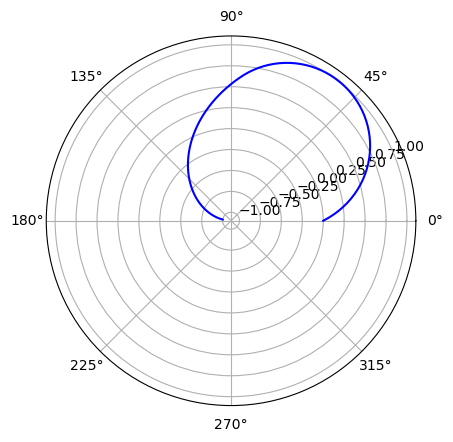

In [10]:
x = [0, 1, 2, 3]
y = [0, 1, 0, -1]

f = interp1d(x, y, kind='quadratic')

x_smooth = np.linspace(0, 3, 100)   # 100 smooth points from 0 to 3
y_smooth = f(x_smooth)  

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.plot(x_smooth, y_smooth, color='blue')